# Pension model

In [1]:
import sys
import os

project_root = os.path.abspath("../")  # one level up from notebook/

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from pension_model.revamp_predictor import TimeSeriesPredictor

import pandas as pd

## Import raw data

In [2]:
dtypes = {
    "Annee": "int64",
    "D_PIB": "float64"
}

raw_df = pd.read_csv("../data/dataset_COR_norm.csv", index_col=False, dtype=dtypes)
raw_df = raw_df.loc[:, ~raw_df.columns.str.contains("^Unnamed")]

## Historical data and projected/scenario data

In [3]:
# Check if the length is a multiple of 69
n_years = 69
assert len(raw_df) % n_years == 0, "Data length must be a multiple of 69"

# Create dictionary of DataFrames
grouped_dfs = {
    f"group_{i}": raw_df.iloc[i*n_years:(i+1)*n_years].reset_index(drop=True)
    for i in range(len(raw_df) // n_years)
}

# Show the first group
print(grouped_dfs["group_0"])

    Annee     D_PIB     PROD    CHO      MI    FEC     ESP_F     ESP_H  \
0    2002  0.117761  0.02786  0.079   97000  1.881  21.40000  17.10000   
1    2003  0.118774  0.00614  0.085  102000  1.891  21.30000  17.10000   
2    2004  0.119571  0.01315  0.089  105128  1.915  22.10000  17.70000   
3    2005  0.121331  0.00955  0.089   92192  1.938  22.00000  17.70000   
4    2006  0.121535  0.02648  0.088  112141  1.997  22.40000  18.00000   
..    ...       ...      ...    ...     ...    ...       ...       ...   
64   2066  0.131398  0.01000  0.050   70000  1.800  26.41802  24.36323   
65   2067  0.131499  0.01000  0.050   70000  1.800  26.49499  24.46490   
66   2068  0.131601  0.01000  0.050   70000  1.800  26.57171  24.56578   
67   2069  0.131750  0.01000  0.050   70000  1.800  26.64818  24.66589   
68   2070  0.131999  0.01000  0.050   70000  1.800  26.72440  24.76522   

      PIB_VAL  PRELEV_REF  CONTRIB_REF   PIB_VOL  
0    1578.330        26.9          2.0  2003.664  
1    1622

In [4]:
# Retail only real values
df_historical_data = grouped_dfs["group_0"]
df_historical_data = df_historical_data[df_historical_data['Annee'] < 2024]

# Remaining all scenario data
# Filter each DataFrame, then concatenate
filtered_dfs = [df[df['Annee'] >= 2024] for df in grouped_dfs.values()]
df_scenarios = pd.concat(filtered_dfs, ignore_index=True)


## Include scenarios?

In [5]:
include_scenarios = True

if include_scenarios:
    # If you want all unique vales (real data + all scenarions), concatenate `df_historical_data` and `df_scenarios`
    df = pd.concat([df_historical_data, df_scenarios], ignore_index=True)
else:
    df = df_historical_data.copy()

In [6]:
print(df.head())
print(df.tail())

   Annee     D_PIB     PROD    CHO      MI    FEC  ESP_F  ESP_H   PIB_VAL  \
0   2002  0.117761  0.02786  0.079   97000  1.881   21.4   17.1  1578.330   
1   2003  0.118774  0.00614  0.085  102000  1.891   21.3   17.1  1622.313   
2   2004  0.119571  0.01315  0.089  105128  1.915   22.1   17.7  1696.108   
3   2005  0.121331  0.00955  0.089   92192  1.938   22.0   17.7  1762.048   
4   2006  0.121535  0.02648  0.088  112141  1.997   22.4   18.0  1846.021   

   PRELEV_REF  CONTRIB_REF   PIB_VOL  
0        26.9          2.0  2003.664  
1        27.6          2.0  2023.056  
2        27.9          2.0  2081.082  
3        27.9          2.0  2120.384  
4        28.0          2.1  2177.933  
     Annee     D_PIB  PROD   CHO     MI  FEC     ESP_F     ESP_H    PIB_VAL  \
393   2066  0.131398  0.01  0.05  70000  1.8  23.99277  21.93565   9250.220   
394   2067  0.131499  0.01  0.05  70000  1.8  24.02340  22.00315   9492.102   
395   2068  0.131601  0.01  0.05  70000  1.8  24.05405  22.07035  

---

# Instantiate the model predictor

In [7]:
# Instantiate the predictor object with the target column
predictor = TimeSeriesPredictor(target_col='D_PIB', model_dir='../models/')

In [8]:
# Step 1: Load and explore data
df = predictor.load_and_explore_data(df)

INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Loading and exploring data...
INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Data loaded: 398 rows, 12 columns
INFO:pension_model.revamp_predictor: Data loaded: 398 rows, 12 columns
INFO:pension_model.revamp_predictor: Memory usage: 0.04 MB
INFO:pension_model.revamp_predictor: ✓ No missing values detected
INFO:pension_model.revamp_predictor: Data types:
Annee            int64
D_PIB          float64
PROD           float64
CHO            float64
MI               int64
FEC            float64
ESP_F          float64
ESP_H          float64
PIB_VAL        float64
PRELEV_REF     float64
CONTRIB_REF    float64
PIB_VOL        float64
dtype: object
INFO:pension_model.revamp_predictor: Target variable (D_PIB) statistics:
count    398.000000
mean       0.135282
std        0.004921


## Data visualization

INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor:Data visualization and pattern analysis...
INFO:pension_model.revamp_predictor:============================================================


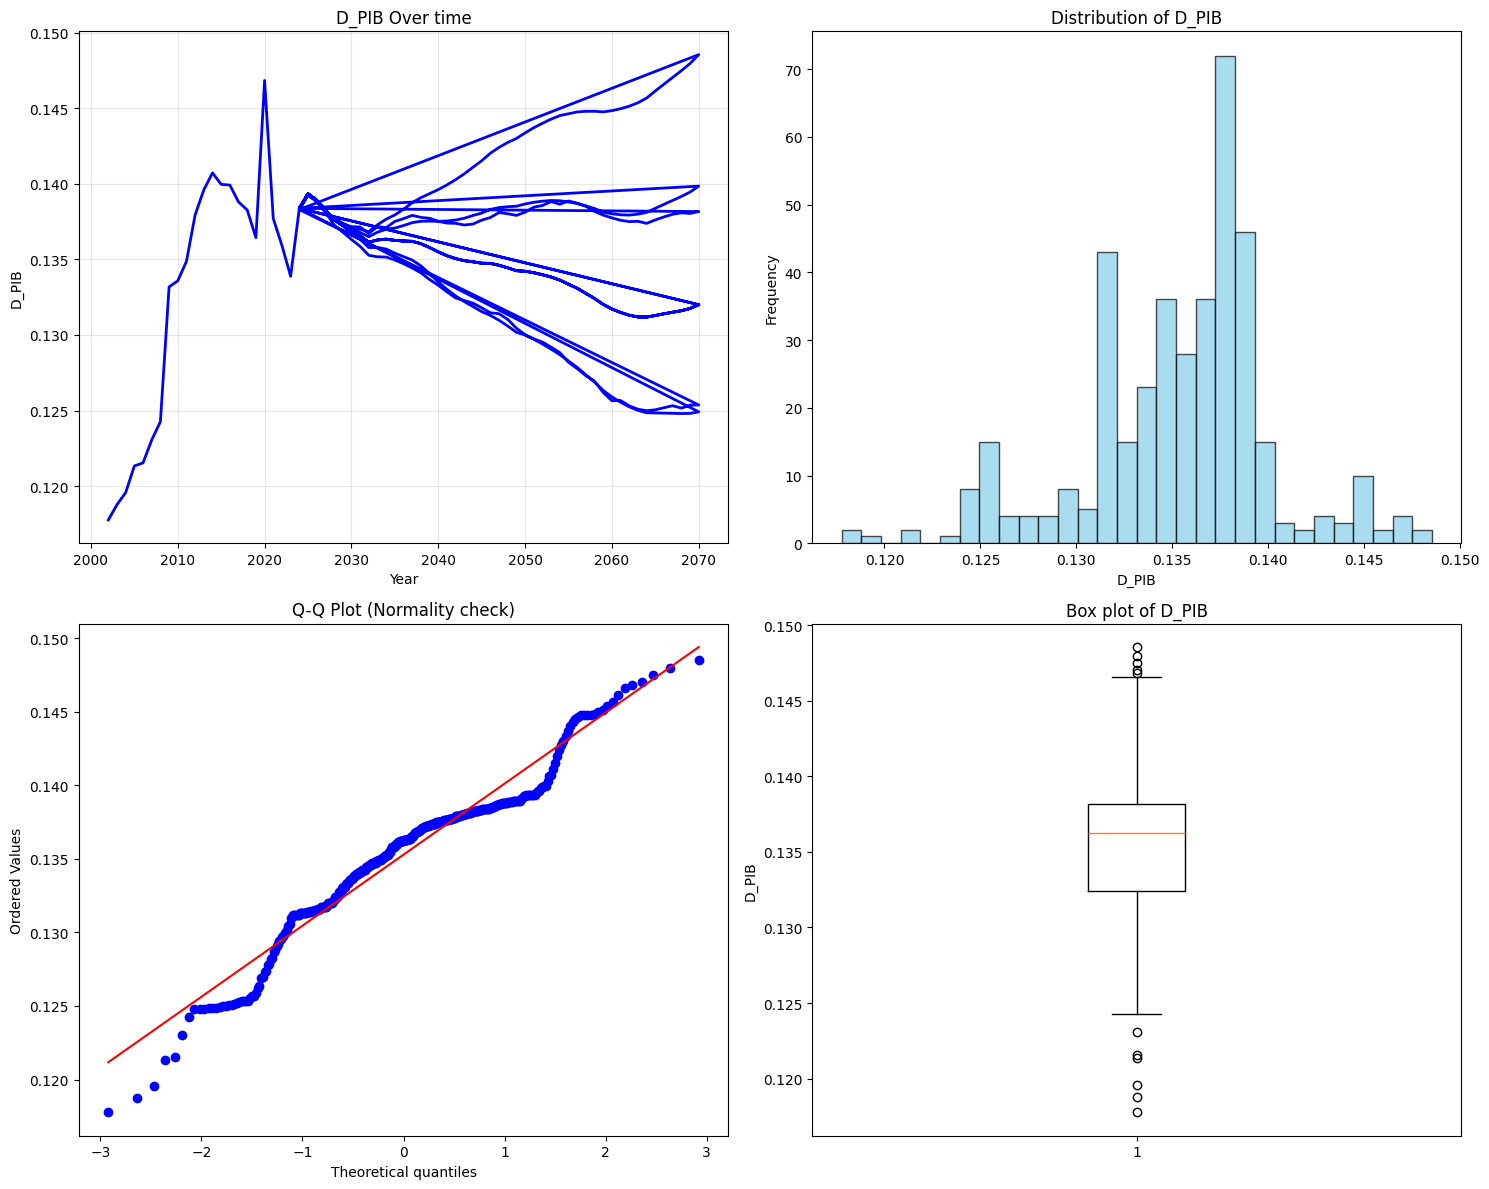

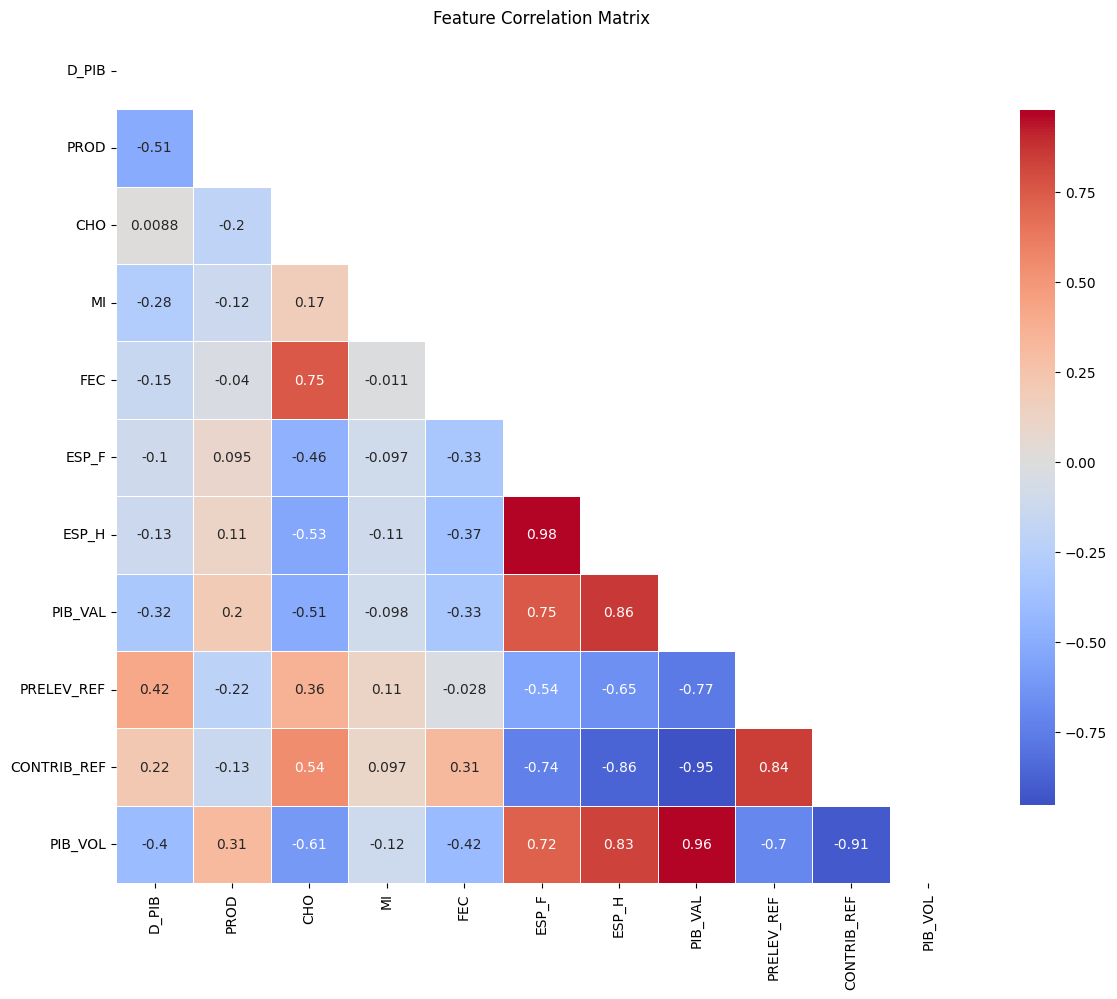

INFO:pension_model.revamp_predictor: Carried out data visualization and returning correlation matrix.


In [9]:
# Step 2: Visualize data
correlation_matrix = predictor.visualize_data()

In [10]:
correlation_matrix

,D_PIB,PROD,CHO,MI,FEC,ESP_F,ESP_H,PIB_VAL,PRELEV_REF,CONTRIB_REF,PIB_VOL
D_PIB,1.000000,-0.507095,0.008838,-0.277427,-0.147255,-0.104555,-0.129930,-0.315483,0.418605,0.220700,-0.403342
PROD,-0.507095,1.000000,-0.198469,-0.124735,-0.040050,0.094897,0.113337,0.197824,-0.216255,-0.131010,0.310648
CHO,0.008838,-0.198469,1.000000,0.174055,0.751548,-0.461851,-0.532904,-0.511013,0.358712,0.539909,-0.609049
MI,-0.277427,-0.124735,0.174055,1.000000,-0.011415,-0.097077,-0.107899,-0.098274,0.112094,0.097061,-0.115302
FEC,-0.147255,-0.040050,0.751548,-0.011415,1.000000,-0.333472,-0.371770,-0.327179,-0.028132,0.313504,-0.415167
ESP_F,-0.104555,0.094897,-0.461851,-0.097077,-0.333472,1.000000,0.975573,0.751834,-0.542618,-0.739529,0.720530
ESP_H,-0.129930,0.113337,-0.532904,-0.107899,-0.371770,0.975573,1.000000,0.861539,-0.654131,-0.863966,0.828914
PIB_VAL,-0.315483,0.197824,-0.511013,-0.098274,-0.327179,0.751834,0.861539,1.000000,-0.766306,-0.950731,0.963395
PRELEV_REF,0.418605,-0.216255,0.358712,0.112094,-0.028132,-0.542618,-0.654131,-0.766306,1.000000,0.843382,-0.700725
CONTRIB_REF,0.220700,-0.131010,0.539909,0.097061,0.313504,-0.739529,-0.863966,-0.950731,0.843382,1.000000,-0.907404


## Perform statistical stets on normality and stationarity

In [11]:
# Step 3: Statistical tests
predictor.statistical_tests()

INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Perform statistical tests and verify assumptions...
INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Normality tests:
INFO:pension_model.revamp_predictor: Jarque-Bera Test: statistic=34.6043, p-value=0.0000
INFO:pension_model.revamp_predictor: Shapiro-Wilk Test: statistic=0.9537, p-value=0.0000
INFO:pension_model.revamp_predictor: ⚠ Data may not be normally distributed
INFO:pension_model.revamp_predictor: Stationary tests:
INFO:pension_model.revamp_predictor: Augmented Dickey-Fuller Test:
INFO:pension_model.revamp_predictor:    ADF Statistic: -4.1368
INFO:pension_model.revamp_predictor:    p-value: 0.0008
INFO:pension_model.revamp_predictor:    Critical Values: {'1%': np.float64(-3.4469295619737665), '5%': np.float64(-2.8688478565083417), '10%': np.float64(-2.57066288555

## Perform feature engineering (to be improved)

In [12]:
# Step 4: Feature engineering
X, y = predictor.feature_engineering()

INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Feature engineering and selection
INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Original features: 10
INFO:pension_model.revamp_predictor: Feature names: ['PROD', 'CHO', 'MI', 'FEC', 'ESP_F', 'ESP_H', 'PIB_VAL', 'PRELEV_REF', 'CONTRIB_REF', 'PIB_VOL']
INFO:pension_model.revamp_predictor: Creating lag features...
INFO:pension_model.revamp_predictor: Features after engineering: 50
INFO:pension_model.revamp_predictor: Samples after cleaning: 393
INFO:pension_model.revamp_predictor: Selected features (20): ['PROD', 'PIB_VAL', 'PRELEV_REF', 'CONTRIB_REF', 'PIB_VOL', 'PROD_lag_1', 'PROD_lag_2', 'PIB_VAL_lag_1', 'PIB_VAL_lag_2', 'PRELEV_REF_lag_1', 'PIB_VOL_lag_1', 'PIB_VOL_lag_2', 'PROD_roll_mean_3', 'PROD_roll_mean_6', 'MI_roll_mean_6', 'PIB_VAL_roll_mean_3', 'PIB_VAL_roll

In [13]:
predictor.feature_names

Index(['PROD', 'PIB_VAL', 'PRELEV_REF', 'CONTRIB_REF', 'PIB_VOL', 'PROD_lag_1',
       'PROD_lag_2', 'PIB_VAL_lag_1', 'PIB_VAL_lag_2', 'PRELEV_REF_lag_1',
       'PIB_VOL_lag_1', 'PIB_VOL_lag_2', 'PROD_roll_mean_3',
       'PROD_roll_mean_6', 'MI_roll_mean_6', 'PIB_VAL_roll_mean_3',
       'PIB_VAL_roll_mean_6', 'PRELEV_REF_roll_mean_3', 'PIB_VOL_roll_mean_3',
       'PIB_VOL_roll_mean_6'],
      dtype='object')

In [14]:
# Step 5: Prepare data
X_scaled, y = predictor.prepare_data_for_modeling()

INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Data preparation and scaling...
INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Applied RobustScaler to features
INFO:pension_model.revamp_predictor: Set up TimeSeriesSplit with 5 folds
INFO:pension_model.revamp_predictor: Data preparation completed. Features: 20


## Train different models

In [15]:
# Step 6: Train models
results = predictor.train_models()

INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Model training and comparison
INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Training Linear Regression...
INFO:pension_model.revamp_predictor:    Set best model, no hyperparameter tuning
INFO:pension_model.revamp_predictor:    Performing cross-validation...
INFO:pension_model.revamp_predictor:    CV RMSE: 0.002544 (+/- 0.002104)
INFO:pension_model.revamp_predictor: Training Ridge...
INFO:pension_model.revamp_predictor:    Performing hyperparameter tuning...
INFO:pension_model.revamp_predictor:    Best parameters: {'alpha': 0.1}
INFO:pension_model.revamp_predictor:    Performing cross-validation...
INFO:pension_model.revamp_predictor:    CV RMSE: 0.002528 (+/- 0.002053)
INFO:pension_model.revamp_predictor: Training Lasso...
INFO:pension_model.revamp_predictor:    Perfo

## Model evaluation

INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Model evaluation and diagnostics...
INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Final Model Performance (Ridge):
INFO:pension_model.revamp_predictor:    RMSE: 0.001626
INFO:pension_model.revamp_predictor:    MAE:  0.001224
INFO:pension_model.revamp_predictor:    R-squared:   0.876232


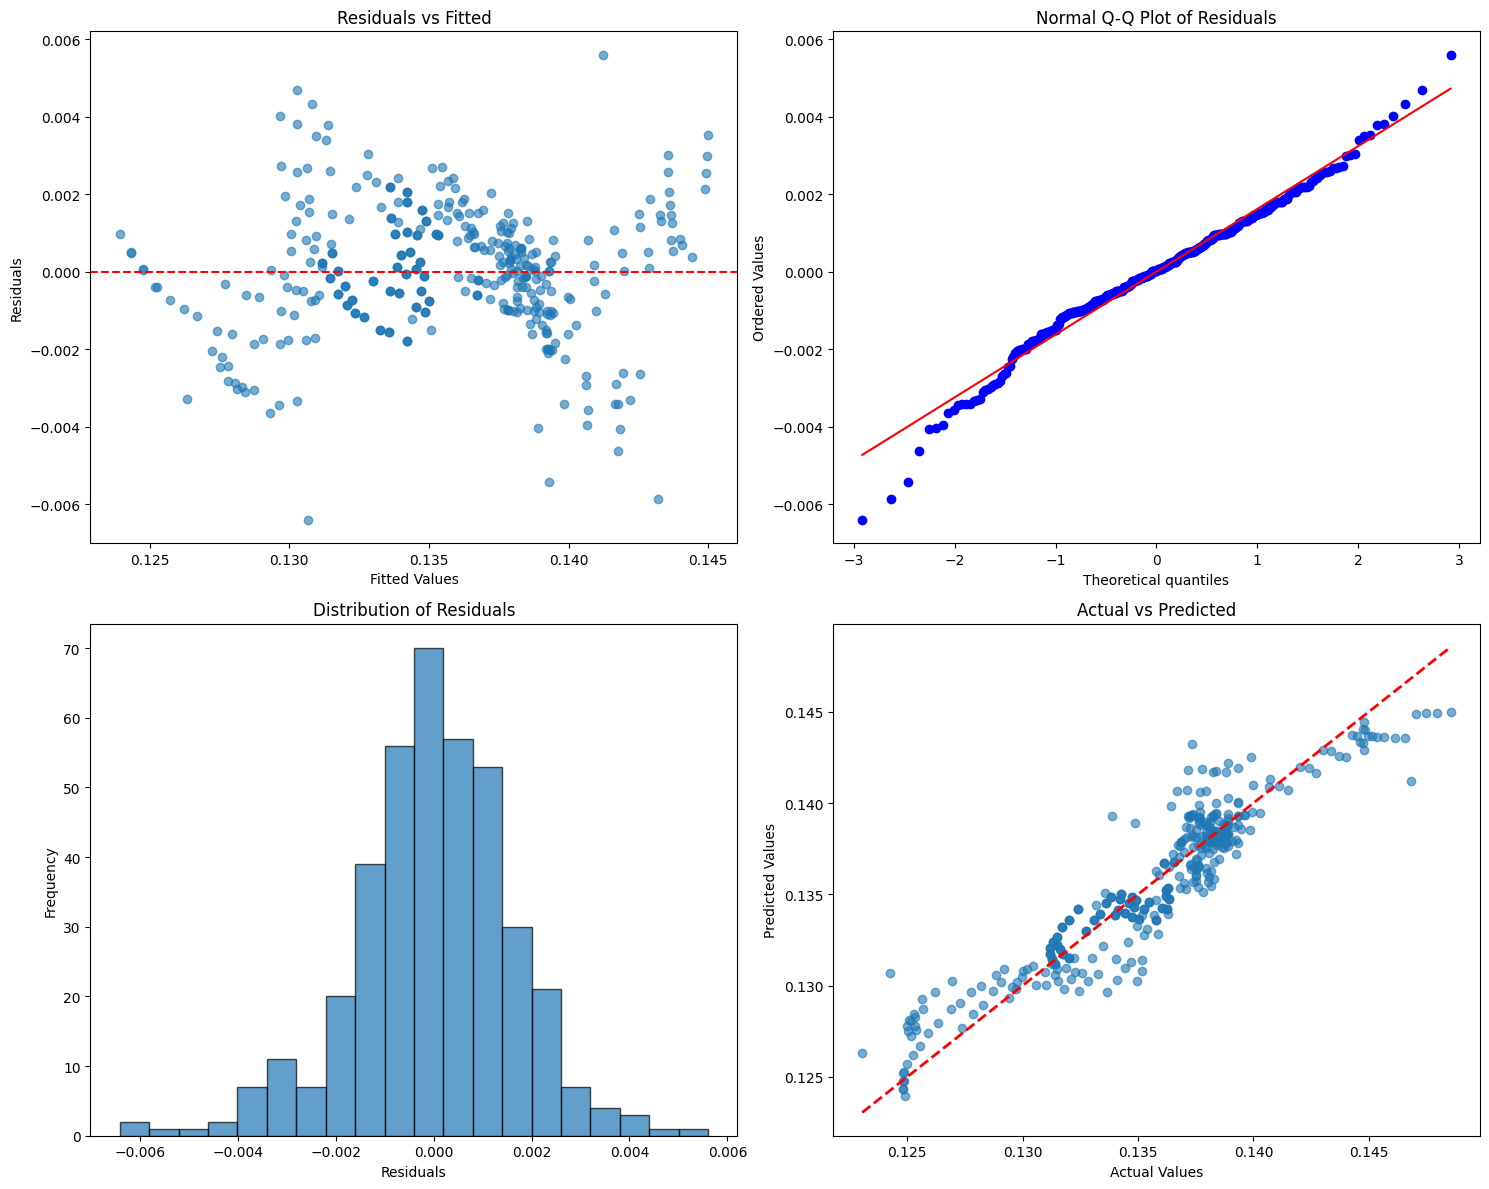

In [16]:
# Step 7: Evaluate best model
evaluation = predictor.evaluate_model()

---
---

## Model comparison

INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Model comparison summary...
INFO:pension_model.revamp_predictor:============================================================
INFO:pension_model.revamp_predictor: Model performance ranking:
            Model  CV_RMSE_Mean  CV_RMSE_Std
            Ridge      0.002528     0.001027
Linear Regression      0.002544     0.001052
            Lasso      0.003282     0.001566
    Random Forest      0.003316     0.001798
Gradient Boosting      0.003364     0.001857
      Elastic Net      0.004707     0.002205


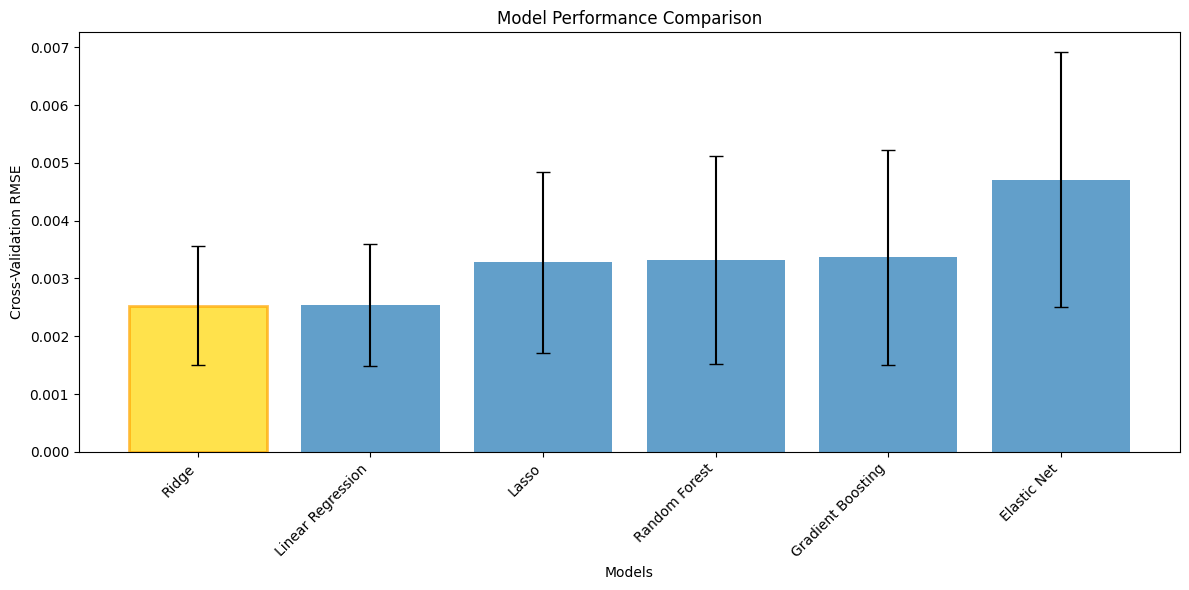

In [17]:
# Step 8: Model comparison
comparison = predictor.model_comparison_summary()

## Save best model

In [18]:
model_path = predictor.save_best_model("production_model_v2")
print(f" Model saved to: {model_path}")

INFO:pension_model.revamp_predictor: Model saved to ..\models\production_model_v2\model.pkl
INFO:pension_model.revamp_predictor: Preprocessing pipeline saved to ..\models\production_model_v2\preprocessing_pipeline.pkl
INFO:pension_model.revamp_predictor: Metadata saved to ..\models\production_model_v2\metadata.json
INFO:pension_model.revamp_predictor: Complete model package saved to ..\models\production_model_v2


 Model saved to: ..\models\production_model_v2


---
---